# Randomized PCA & Virtual Centering

While **SVD** is the mathematical engine, **PCA (Principal Component Analysis)** is often the tool Data Scientists need for analysis.

Mathematically, **PCA is simply SVD performed on centered data**.
If $X$ is your data matrix and  is the row-vector of column means, PCA is the SVD of:

$$
X_{\text{centered} = X - \mu}
$$

### The "Big Data" Problem

If you have a massive **Sparse Matrix** (mostly zeros), subtracting the mean is dangerous.

1. The mean vector  is usually non-zero everywhere.
2. Calculating $X - \mu$ turns every single zero entry into $-\mu_j$.
3. **The matrix becomes DENSE.** A 1GB sparse matrix can instantly explode to 100GB, crashing your RAM (Out-Of-Memory error).

### The Solution: Virtual Centering

**randomized-svd** implements a smart **Virtual Centering** technique.
Instead of calculating $C = X - \mu$ explicitly, we create a Linear Operator that computes matrix-vector products  on the fly:

$$
(X - \mu)v = Xv - \mu(v)
$$

This allows us to run PCA on huge sparse matrices without ever allocating the dense centered version.

In [1]:
import time
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Import rsvd (standard) and rpca (virtual centering)
from randomized_svd import rsvd, rpca

print("Libraries loaded.")


Libraries loaded.


## 1. The Concept: SVD vs. PCA

Let's visualize why you can't just use `rsvd` if you want PCA.
We generate a cloud of data points centered far away from the origin $(0,0)$.

* **SVD** captures the "strongest energy" relative to the origin.
* **PCA** captures the "strongest variance" relative to the data's center of mass.

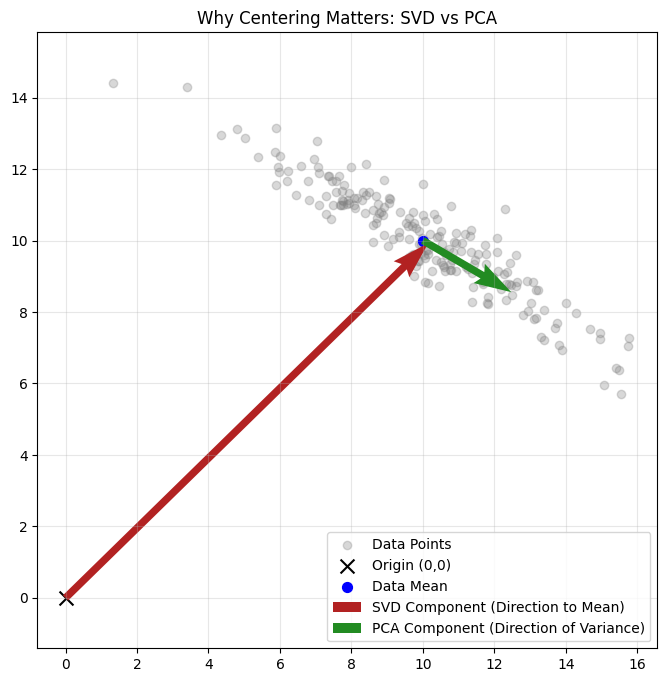

In [2]:
# 1. Generate Data centered at (10, 10)
np.random.seed(42)
mean_shift = np.array([10.0, 10.0])

# Create a stretched cloud
cloud = np.random.randn(200, 2) @ np.diag([3.0, 0.5]) 

# Rotate it slightly (30 degrees)
theta = np.radians(30)
R = np.array([[np.cos(theta), -np.sin(theta)], 
              [np.sin(theta),  np.cos(theta)]])
X = (cloud @ R) + mean_shift

# 2. Compute Standard rSVD (No Centering)
# SVD sees the vector from origin (0,0) to the cloud (10,10) as the main component
U_svd, S_svd_mat, Vt_svd = rsvd(X, t=1)
S_svd = np.diag(S_svd_mat) if S_svd_mat.ndim == 2 else S_svd_mat # Robustness check
vec_svd = Vt_svd[0] * S_svd[0] / np.sqrt(len(X)) 

# 3. Compute rPCA (With Virtual Centering)
# PCA sees the spread of the cloud itself
U_pca, S_pca_mat, Vt_pca = rpca(X, t=1)
S_pca = np.diag(S_pca_mat) if S_pca_mat.ndim == 2 else S_pca_mat # Robustness check
vec_pca = Vt_pca[0] * S_pca[0] / np.sqrt(len(X))

# --- Visualization ---
plt.figure(figsize=(8, 8))
plt.scatter(X[:, 0], X[:, 1], alpha=0.3, label='Data Points', color='gray')
plt.scatter([0], [0], c='black', marker='x', s=100, label='Origin (0,0)')
plt.scatter(mean_shift[0], mean_shift[1], c='blue', marker='o', s=50, label='Data Mean')

# Plot SVD Component
plt.quiver(0, 0, vec_svd[0], vec_svd[1], angles='xy', scale_units='xy', scale=1, 
           color='firebrick', label='SVD Component (Direction to Mean)', width=0.012)

# Plot PCA Component (shifted to data mean for visualization)
plt.quiver(mean_shift[0], mean_shift[1], vec_pca[0], vec_pca[1], angles='xy', scale_units='xy', scale=1, 
           color='forestgreen', label='PCA Component (Direction of Variance)', width=0.012)

plt.title("Why Centering Matters: SVD vs PCA")
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

## 2. The "Killer Feature": Sparse Matrix Support

Now let's simulate a scenario that would crash standard implementations without specialized solvers.

We create a **large sparse matrix** ($10000 \times 10000$) with **1% density**.

* **Sparse Size:**  24 MB.
* **Dense Centered Size:**  800 MB.

If we tried to center this explicitly (`X - X.mean()`), Python would try to allocate the full 800 MB (plus overhead), essentially wasting RAM on zeros.
`rpca` handles this virtually.

In [3]:
N = 10000
density = 0.01

print(f"Generating {N}x{N} Sparse Matrix (Density: {density:.0%})...")
np.random.seed(42)
X_sparse = sp.rand(N, N, density=density, format='csr')

# Calculate memory usage
# Sparse: data (float64) + indices (int32) + indptr (int32)
sparse_bytes = X_sparse.data.nbytes + X_sparse.indices.nbytes + X_sparse.indptr.nbytes
dense_bytes = N * N * 8  # 8 bytes per float64

print(f"💾 Memory required for Sparse storage:  ~{sparse_bytes / 1e6:.2f} MB")
print(f"💥 Memory required for Centering (Dense): ~{dense_bytes / 1e6:.2f} MB")
print(f"   -> Expansion factor: {dense_bytes / sparse_bytes:.1f}x")

print("\nRunning rPCA with Virtual Centering...")
start_time = time.perf_counter()

# This works because rpca wraps X_sparse in a LinearOperator
# It NEVER creates the 800MB dense matrix.
U, S, Vt = rpca(X_sparse, t=50)

elapsed = time.perf_counter() - start_time
print(f"✅ Done in {elapsed:.4f} seconds.")

# Robustness: Check if S is returned as diagonal matrix or 1D array
S_vec = np.diag(S) if S.ndim == 2 else S
print(f"   Computed {len(S_vec)} principal components.")
print(f"   Top singular value: {S_vec[0]:.4f}")


Generating 10000x10000 Sparse Matrix (Density: 1%)...
💾 Memory required for Sparse storage:  ~12.04 MB
💥 Memory required for Centering (Dense): ~800.00 MB
   -> Expansion factor: 66.4x

Running rPCA with Virtual Centering...
✅ Done in 0.1036 seconds.
   Computed 50 principal components.
   Top singular value: 8.5980


## 3. Correctness Verification

Finally, we verify that our randomized implementation produces the same results (singular values) as Scikit-Learn's reference implementation on a dense dataset where both can run.

Running Scikit-Learn PCA (n_iter=2)...
Running rPCA (p=2)...


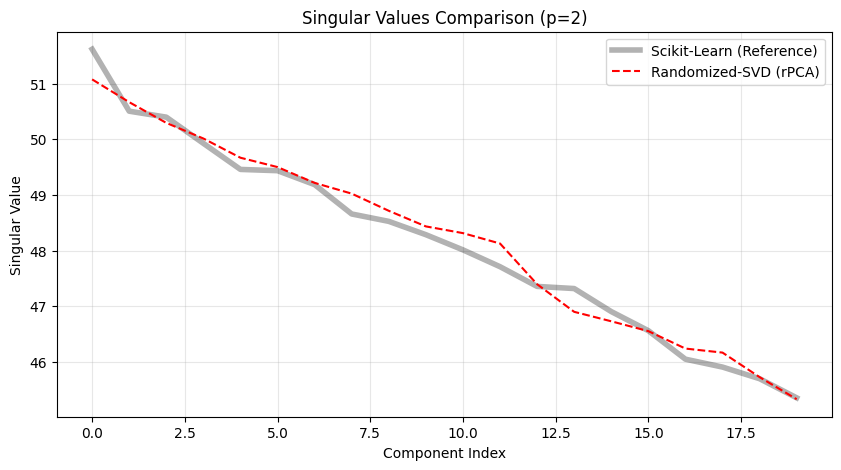


Relative Error vs Sklearn: 4.99e-03
✅ Validation Passed: Results are statistically consistent.


In [ ]:
# Generate smaller dense data for comparison
# Non-zero mean is crucial to test centering logic
np.random.seed(42)
X_dense = np.random.randn(1000, 500) + 5.0 
k = 20

# p=2 (Power Iterations)
power_iterations = 2 

# 1. Scikit-Learn PCA (Reference)
print(f"Running Scikit-Learn PCA (n_iter={power_iterations})...")
sklearn_pca = PCA(
    n_components=k, 
    svd_solver='randomized', 
    iterated_power=power_iterations,
    random_state=42
)
sklearn_pca.fit(X_dense)
s_sklearn = sklearn_pca.singular_values_

# 2. Our rPCA
print(f"Running rPCA (p={power_iterations})...")
_, S_ours_mat, _ = rpca(X_dense, t=k, p=power_iterations)
s_ours = np.diag(S_ours_mat) if S_ours_mat.ndim == 2 else S_ours_mat

# --- Comparison ---
plt.figure(figsize=(10, 5))
plt.plot(s_sklearn, 'k-', label='Scikit-Learn (Reference)', linewidth=4, alpha=0.3)
plt.plot(s_ours, 'r--', label='Randomized-SVD (rPCA)')
plt.title(f'Singular Values Comparison (p={power_iterations})')
plt.xlabel('Component Index')
plt.ylabel('Singular Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Numerical Check
# Relative Error: ||s_ref - s_ours|| / ||s_ref||
error = np.linalg.norm(s_sklearn - s_ours) / np.linalg.norm(s_sklearn)
print(f"\nRelative Error vs Sklearn: {error:.2e}")

if error < 1e-2:
    print("✅ Validation Passed: Results are statistically consistent.")
else:
    print(f"⚠️ Validation Warning: Error is still high ({error:.2%}). Check oversampling settings.")
